### Detecção de anomalias com Variational Auto Encoder
----


In [ ]:
import pandas as pd
import sqlite3
import prettytable
from pathlib import Path
import os
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

prettytable.DEFAULT = 'DEFAULT'

In [3]:
db_path = Path("KPIs") / "KPIs.db"
if not db_path.exists():
    raise FileNotFoundError(f"Database not found: {db_path.resolve()}")

conn = sqlite3.connect(db_path)
print("Connected to:", db_path.resolve())

Connected to: /home/tiago/Documentos/COURSERA_IBM_DATA_SCIENCE/TIM_KPIS_VAE/KPIs/KPIs.db


In [4]:
# Show available tables/views
sqlite_master = pd.read_sql_query(
    """
    SELECT name, type
    FROM sqlite_master
    WHERE type IN ('table', 'view')
    ORDER BY type, name
    """,
    conn,
)
sqlite_master

,name,type
0,KPI4G,table
1,KPI5G,table


In [5]:
df4G = pd.read_sql_query("SELECT * FROM KPI4G", conn)
df4G.head()

,Dia,Estado,ANF,Municipio,Fornecedor,Site,Disp,ACC_ERAB,DROP_ERAB,TPUT_USER_DL,TPUT_USER_UL,Usuarios,PRB_AVAIL,PRB_UTIL_DL,PRB_UTIL_UL,VOL_TOTAL_GB,PLOSS
0,2026-02-27,PB,83,AREIA,NOKIA,18NLAEAE00,100.0,97.70,2.15,18.17,0.40,17.0,75.0,2.58,2.81,7.0,0.00
1,2026-02-27,PB,83,ALHANDRA,NOKIA,18NLAHAH00,100.0,99.71,0.64,6.39,0.31,275.0,99.0,53.98,45.72,258.0,0.00
2,2026-02-27,PE,81,AGUA PRETA,NOKIA,18NLAJAJ00,100.0,99.85,0.20,7.79,0.53,64.0,50.0,15.16,14.31,39.0,36.36
3,2026-02-27,RN,84,ANGICOS,NOKIA,18NLAKAK00,100.0,99.15,2.97,5.28,0.28,103.0,75.0,18.30,21.54,48.0,0.02
4,2026-02-27,PI,86,ALTOS,NOKIA,18NLALAL00,100.0,99.66,0.39,16.82,2.77,16.0,49.0,2.64,1.68,6.0,100.00


### Modelo VAE
-----

In [6]:
# --- CONFIG ---
out_dir = "vae_output"
window_size = 3
latent_dim = 5
beta = 0.7
batch_size = 512
epochs = 80
random_state = 42
# --------------

os.makedirs(out_dir, exist_ok=True)

2026-02-28 22:05:01.211958: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-28 22:05:01.296114: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-28 22:05:03.885771: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [10]:
%%time
df = pd.read_sql_query("SELECT * FROM KPI4G", conn)
df['Dia'] = pd.to_datetime(df['Dia'], errors='coerce')
df = df.sort_values(['Site','Dia']).reset_index(drop=True)

5.16 s ± 794 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [12]:
%%time

# identificar colunas KPI (tudo após 'Site')
cols = list(df.columns)

if 'Site' not in cols:
    raise RuntimeError("Coluna 'Site' não encontrada.")

site_idx = cols.index('Site')
kpi_cols = cols[site_idx+1:]

print("KPIs:", kpi_cols)

# dataframe apenas com colunas necessárias
df_kpi = df[['Dia','Site'] + kpi_cols].copy()

# converter para numérico
for c in kpi_cols:
    df_kpi[c] = pd.to_numeric(df_kpi[c], errors='coerce')

# ordenar apenas uma vez (importante)
df_kpi = df_kpi.sort_values(['Site','Dia'])


# =========================
# Construção janelas 3 dias
# =========================

X_list = []
idx_list = []

for site, g in df_kpi.groupby('Site'):

    vals = g[kpi_cols].values
    dates = g['Dia'].values

    n = vals.shape[0]

    if n < window_size:
        continue

    for i in range(n - window_size + 1):

        X_list.append(
            vals[i:i+window_size].reshape(-1)
        )

        idx_list.append(
            (site, dates[i+window_size-1])
        )


X = np.vstack(X_list)

print("Amostras (janelas):", X.shape)


# =========================
# Train / Validation split
# =========================

X_train, X_val = train_test_split(
    X,
    test_size=0.2,
    random_state=random_state,
    shuffle=True
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)


# =========================
# Normalização
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


joblib.dump(
    scaler,
    os.path.join(out_dir,"scaler.pkl")
)

print("Scaler salvo")

KPIs: ['Disp', 'ACC_ERAB', 'DROP_ERAB', 'TPUT_USER_DL', 'TPUT_USER_UL', 'Usuarios', 'PRB_AVAIL', 'PRB_UTIL_DL', 'PRB_UTIL_UL', 'VOL_TOTAL_GB', 'PLOSS']
Amostras (janelas): (575804, 33)
Train: (460643, 33)
Val: (115161, 33)
Scaler salvo
CPU times: user 8.29 s, sys: 2.33 s, total: 10.6 s
Wall time: 10.7 s


In [39]:
%%time


input_dim = X_train_scaled.shape[1]

# ======================
# Encoder
# ======================

encoder_inputs = layers.Input(shape=(input_dim,))

x = layers.Dense(64, activation='relu')(encoder_inputs)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(16, activation='relu')(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

@tf.keras.utils.register_keras_serializable()
def sampling(args):

    zm, zv = args
    eps = tf.random.normal(
        shape=(tf.shape(zm)[0], latent_dim)
    )
    return zm + tf.exp(0.5*zv)*eps

z = layers.Lambda(sampling)([z_mean,z_log_var])

encoder = Model(
    encoder_inputs,
    [z_mean,z_log_var,z],
    name="encoder"
)

# ======================
# Decoder
# ======================

latent_inputs = layers.Input(shape=(latent_dim,))

d = layers.Dense(16,activation='relu')(latent_inputs)
d = layers.Dense(32,activation='relu')(d)
d = layers.Dense(64,activation='relu')(d)

decoder_outputs = layers.Dense(input_dim)(d)

decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

# ======================
# VAE Custom Model
# ======================
class VAE(Model):

    def __init__(self, encoder, decoder, beta=1.0):

        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta


    def call(self, inputs):

        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    def train_step(self, data):

        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.square(data - reconstruction),
                    axis=1
                ))

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                ))
            loss = recon_loss + self.beta * kl_loss

        grads = tape.gradient(
            loss,
            self.trainable_weights
        )

        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )
        return {
            "loss": loss,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss
        }

vae = VAE(
    encoder,
    decoder,
    beta=beta
)

vae.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss = lambda y_true, y_pred: 0.0
)

encoder.summary()
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_117 (Dense)   │ (None, 64)        │      2,176 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_118 (Dense)   │ (None, 32)        │      2,080 │ dense_117[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_119 (Dense)   │ (None, 16)        │        528 │ dense_118[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_120 (Dense)   │ (None, 5)         │         85 │ dense_119[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_121 (Dense)   │ (None, 5)         │         85 │ dense_119[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 5)         │          0 │ dense_120[0][0],  │
│                     │                   │            │ dense_121[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,954 (19.35 KB)

 Trainable params: 4,954 (19.35 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_122 (Dense)               │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_123 (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_124 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_125 (Dense)               │ (None, 33)             │         2,145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

CPU times: user 240 ms, sys: 11 ms, total: 251 ms
Wall time: 273 ms


In [40]:
%%time
# Hiperparâmetros (ajuste conforme necessário)
epochs_pretrain = 30           # curto - apenas para estimar erro
epochs_final = epochs          # pode usar sua variável epochs original
batch_size = batch_size        # usa variável que você já tem
k_mad = 4                     # multiplicador MAD (3 é razoável; 4 se quiser mais conservador)

# -------------------------
# EarlyStopping para pré-treino
# -------------------------
es_pre = EarlyStopping(
    monitor='loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# -------------------------
# Pré-treino (modelo inicial, só para calcular erros)
# -------------------------
vae_pre = VAE(encoder, decoder, beta=beta)   # usa as definições já existentes
vae_pre.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=lambda y_true, y_pred: 0.0
)

vae_pre.fit(
    X_train_scaled,
    X_train_scaled,   # dummy target (seu train_step usa data[0])
    epochs=epochs_pretrain,
    batch_size=batch_size,
    validation_data=(X_val_scaled, X_val_scaled),
    callbacks=[es_pre],
    verbose=2
)

# -------------------------
# Erro de reconstrução por amostra (treino)
# -------------------------
X_train_pred = vae_pre.predict(X_train_scaled, batch_size=batch_size)
train_error = np.mean((X_train_scaled - X_train_pred)**2, axis=1)

# -------------------------
# Threshold robusto via MAD (ou troque para percentil se preferir)
# -------------------------
median = np.median(train_error)
mad = np.median(np.abs(train_error - median))
threshold = median + k_mad * mad

# Se preferir percentil 95:
# threshold = np.percentile(train_error, 95)

mask_train = train_error < threshold
X_clean = X_train_scaled[mask_train]

print(f"Treino: original={X_train_scaled.shape[0]}, clean={X_clean.shape[0]}, removidos={X_train_scaled.shape[0]-X_clean.shape[0]}")
if X_clean.shape[0] < X_train_scaled.shape[0] * 0.6:
    print("WARNING: >40% dos exemplos foram removidos — verifique threshold ou inspeção dos dados.")

# -------------------------
# (Opcional) validar threshold também em X_val — se ficar vazio, volta para X_val_scaled
# -------------------------
X_val_pred = vae_pre.predict(X_val_scaled, batch_size=batch_size)
val_error = np.mean((X_val_scaled - X_val_pred)**2, axis=1)
mask_val = val_error < threshold
X_val_clean = X_val_scaled[mask_val]
if X_val_clean.shape[0] < max(1, int(0.1 * X_val_scaled.shape[0])):  # se validação muito pequena, keep original
    X_val_clean = X_val_scaled
    print("Validação filtrada ficou muito pequena — mantendo X_val_scaled para validação final.")

# -------------------------
# Recriar modelos com pesos reinicializados
# -------------------------
# clonagem é prática conveniente: mantém arquitetura, zera pesos
encoder_clean = tf.keras.models.clone_model(encoder)
decoder_clean = tf.keras.models.clone_model(decoder)

# build para garantir shapes (útil para alguns backends)
encoder_clean.build((None, X_train_scaled.shape[1]))
decoder_clean.build((None, latent_dim))

vae_final = VAE(encoder_clean, decoder_clean, beta=beta)
vae_final.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=lambda y_true, y_pred: 0.0
)

# -------------------------
# EarlyStopping para treino final
# -------------------------
es_final = EarlyStopping(
    monitor='loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# -------------------------
# Treino final no conjunto limpo
# -------------------------
history = vae_final.fit(
    X_clean,
    X_clean,
    epochs=epochs_final,
    batch_size=batch_size,
    validation_data=(X_val_clean, X_val_clean),
    callbacks=[es_final],
    verbose=2
)

Epoch 1/30
900/900 - 13s - 15ms/step - kl_loss: 5.4744 - loss: 10.2080 - reconstruction_loss: 6.3760 - val_loss: 0.0000e+00
Epoch 2/30
900/900 - 6s - 6ms/step - kl_loss: 5.4672 - loss: 9.2212 - reconstruction_loss: 5.3942 - val_loss: 0.0000e+00
Epoch 3/30
900/900 - 9s - 10ms/step - kl_loss: 5.2536 - loss: 9.3181 - reconstruction_loss: 5.6406 - val_loss: 0.0000e+00
Epoch 4/30
900/900 - 8s - 8ms/step - kl_loss: 5.6764 - loss: 9.2008 - reconstruction_loss: 5.2273 - val_loss: 0.0000e+00
Epoch 5/30
900/900 - 7s - 8ms/step - kl_loss: 5.5999 - loss: 9.2047 - reconstruction_loss: 5.2847 - val_loss: 0.0000e+00
Epoch 6/30
900/900 - 6s - 7ms/step - kl_loss: 5.4803 - loss: 8.9409 - reconstruction_loss: 5.1047 - val_loss: 0.0000e+00
Epoch 7/30
900/900 - 7s - 7ms/step - kl_loss: 5.4364 - loss: 8.5076 - reconstruction_loss: 4.7021 - val_loss: 0.0000e+00
Epoch 8/30
900/900 - 7s - 8ms/step - kl_loss: 5.6928 - loss: 8.5033 - reconstruction_loss: 4.5183 - val_loss: 0.0000e+00
Epoch 9/30
900/900 - 6s - 7m

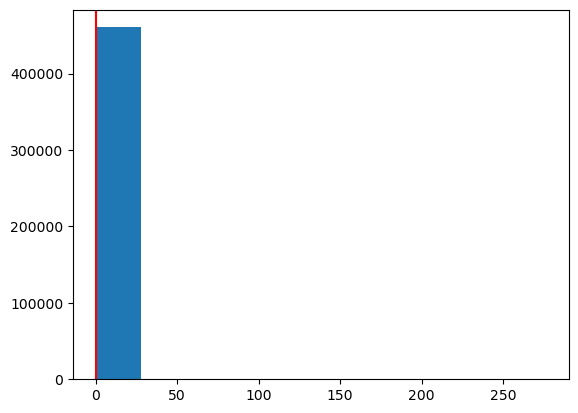

In [42]:
plt.hist(train_error, bins=10)
plt.axvline(threshold, color='r')
plt.show()

In [45]:
%%time
# salvar
# garantir que as próximas células usem o modelo treinado final
vae = vae_final

model_path = os.path.join(out_dir, "vae_model.keras")

try:
	# tenta salvar o modelo completo (pode falhar em modelos subclassed/custom)
	vae_final.save(model_path)
	print("Modelo completo salvo em:", model_path)
except Exception as e:
	# fallback robusto: salvar pesos
	model_path = os.path.join(out_dir, "vae_model.weights.h5")
	vae_final.save_weights(model_path)
	print("Aviso ao salvar modelo completo:", e)
	print("Pesos do modelo salvos em:", model_path)

joblib.dump({'latent_dim': latent_dim, 'beta': beta}, os.path.join(out_dir, 'config.pkl'))
print("Config salva em:", os.path.join(out_dir, 'config.pkl'))


Aviso ao salvar modelo completo: 
Object VAE was created by passing
non-serializable argument values in `__init__()`,
and therefore the object must override `get_config()` in
order to be serializable. Please implement `get_config()`.

Example:


class CustomLayer(keras.layers.Layer):
    def __init__(self, arg1, arg2, **kwargs):
        super().__init__(**kwargs)
        self.arg1 = arg1
        self.arg2 = arg2

    def get_config(self):
        config = super().get_config()
        config.update({
            "arg1": self.arg1,
            "arg2": self.arg2,
        })
        return config

Pesos do modelo salvos em: vae_output/vae_model.weights.h5
Config salva em: vae_output/config.pkl
CPU times: user 137 ms, sys: 18 ms, total: 155 ms
Wall time: 194 ms


In [48]:
%%time
# 7) scores e threshold (99.5 percentile do treino)
X_train_pred = vae_final.predict(X_clean, verbose=0)
train_mse = np.mean(np.square(X_clean - X_train_pred), axis=1)
threshold = np.percentile(train_mse, 99.5)
print("Threshold (99.5 pctl treino limpo) =", threshold)

# 8) aplicar ao conjunto completo para obter score por janela e última janela por site
# idx_list contém (site, Dia) na mesma ordem de X
idx_df = pd.DataFrame(idx_list, columns=['Site','Dia'])
X_scaled_all = scaler.transform(X)
X_all_pred = vae_final.predict(X_scaled_all, verbose=0)
scores_all = np.mean(np.square(X_scaled_all - X_all_pred), axis=1)
idx_df['score'] = scores_all

# última janela por site
last_per_site = idx_df.sort_values('Dia').groupby('Site').tail(1).reset_index(drop=True)
site_stats = idx_df.groupby('Site')['score'].agg(['mean','std','count']).reset_index().rename(columns={'mean':'mu','std':'sigma','count':'n'})
last_per_site = last_per_site.merge(site_stats, on='Site', how='left')
last_per_site['zscore'] = (last_per_site['score'] - last_per_site['mu']) / (last_per_site['sigma'].replace(0, np.nan))
last_per_site['anomaly_global'] = last_per_site['score'] > threshold
last_per_site = last_per_site.sort_values('score', ascending=False)


Threshold (99.5 pctl treino limpo) = 0.5441425142372438
CPU times: user 2min 5s, sys: 13.1 s, total: 2min 18s
Wall time: 1min 58s


Top 20 anomalias (score):
            Site        Dia       score        mu      sigma    zscore  anomaly_global
5176   4G-FLCED3 2026-02-27  154.247557  4.038797  25.051016  5.996114            True
2878   4G-FLSBJ2 2026-02-27  124.509865  9.984522  31.844743  3.596366            True
3346   4G-NTPGJ4 2026-02-27  100.056919  4.730527  22.269641  4.280554            True
1780    NLBAX504 2026-02-27    9.912975  2.457037   2.737981  2.723152            True
2294   4G-FSCE13 2026-02-27    6.718058  0.526150   1.230761  5.030959            True
3843   4N-FSCN28 2026-02-27    6.190740  0.834367   4.100079  1.306407            True
1589   3SLCMAD01 2026-02-27    5.739849  0.274991   0.615834  8.873911            True
1265    NLNONO00 2026-02-27    4.757646  0.278459   0.682553  6.562406            True
2393   4G-PAPAJ1 2026-02-27    4.711180  0.301221   0.654955  6.733224            True
4400  18NLCPIR02 2026-02-27    4.682585  0.370599   0.905770  4.760576            True
5220   4G-SBSBJ0 

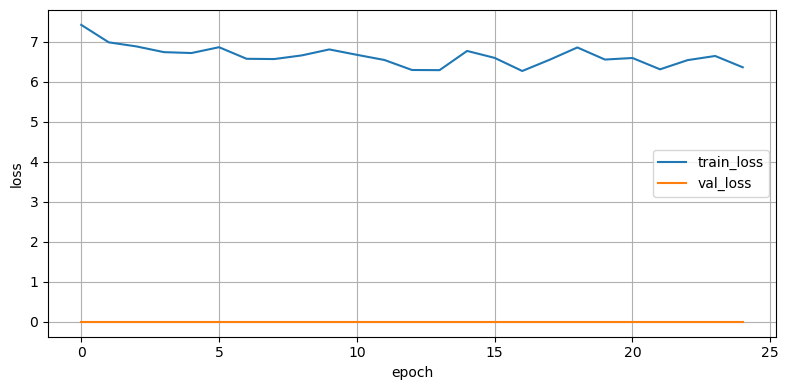

Artefatos gerados em: vae_output
Arquivos: ['last_per_site_scores.csv', 'config.pkl', 'all_window_scores.csv', 'vae_model.weights.h5', 'vae_model.keras', 'scaler.pkl']
CPU times: user 3.89 s, sys: 185 ms, total: 4.08 s
Wall time: 4.16 s


In [50]:
%%time
# salvar CSVs
last_per_site.to_csv(os.path.join(out_dir, "last_per_site_scores.csv"), index=False)
idx_df.to_csv(os.path.join(out_dir, "all_window_scores.csv"), index=False)

# 9) mostrar top20
print("Top 20 anomalias (score):")
print(last_per_site[['Site','Dia','score','mu','sigma','zscore','anomaly_global']].head(100).to_string())

# 10) plot loss
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='train_loss')
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Artefatos gerados em:", out_dir)
print("Arquivos:", os.listdir(out_dir))